# SATARK 2.0 — Predictive Cybercrime Risk Forecasting

**Objective:** Build a genuine predictive model from the 2017–2022 cybercrime dataset.

This version changes the modeling problem to a **next-year forecasting task**:

> Given a state's district, its current-year cybercrime profile, and the current year, predict the district's **total cybercrime offences in the following year**.

This avoids the original target-leakage problem where `total` was created by summing already-scaled predictors. The model learns from historical observations and is evaluated chronologically on unseen future years.

### Main outputs
- Clean district-year dataset
- Exploratory analysis
- Time-aware train/validation/test split
- CatBoost regression model using numerical crime features + categorical geography
- Baseline comparison
- MAE, RMSE, R² and MAPE
- Feature importance
- Actual-vs-predicted analysis
- Reusable `predict_next_year()` function
- Risk classification derived from the predicted burden


## 1. Why the model has been changed

The previous implementation had four important modeling problems:

1. **Target leakage:** the target was created after Min-Max scaling the crime variables, so the target was an artificial sum rather than the original crime burden.
2. **No real future prediction:** a random train/test split allowed observations from the same time period to appear in both sets.
3. **Geography was handled incorrectly:** `OneHotEncoder` was used as if it were a label encoder and its multi-column output was assigned to one column.
4. **Only three predictors were used:** year, state ID and district code discarded most of the cybercrime information.

### New formulation

For each district-year record:
- **Features:** current-year crime counts, current total burden, year, state and district.
- **Target:** next year's `total_offences_ip`.
- **Training:** target years 2018–2020.
- **Validation:** target year 2021.
- **Final test:** target year 2022.

This makes the test genuinely future-oriented.


In [1]:
# 2. Imports and configuration
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

DATA_PATH = "cybercrime_dataset_17-22.xlsx"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "/content/cybercrime_dataset_17-22.xlsx"

print("Data path:", DATA_PATH)


Data path: cybercrime_dataset_17-22.xlsx


In [2]:
# 3. Load raw data
raw = pd.read_excel(DATA_PATH)

print("Raw shape:", raw.shape)
display(raw.head())
raw.info()


Raw shape: (5322, 38)


,id,year,state_nm,state_code,district_name,district_cd,reg_circle,tampering_computer_source_documents,ransom_ware,offences_other_than_ransom_ware,dishonestly_recv_stolen_cmp_resrc_or_comm_device,identity_theft,cheating_by_personation_by_using_computer_resource,violation_of_privacy,cyber_terrorism,other_sections_it_act,interception_or_monitoring_or_decryption_of_info,un_athryz_access_atmpt_access_prct_comp_sys,abetment_to_commit_offences,attempt_to_commit_offences,other_sections_of_it_act,cyber_stalking_bullying_of_women_children,data_theft,credit_card_debit_card_fraud,atms_fraud,online_banking_fraud,otp_frauds,other_frauds,cheating,forgery,defamation_morphing,fake_profile,currency_counterfeiting,stamps_counterfeiting,cyber_blackmailing_threatening,fake_news_on_social_media,other_offences,total_offences_ip
0,0,2017,Jammu And Kashmir,1,ANANTNAG,1,Anantnag,0,NaN,0,0,0,0,0,0,0,0,NaN,0,NaN,0,0,0,0,NaN,0,0,0,0,NaN,0,0,NaN,0,0,0,0,0
1,1,2017,Jammu And Kashmir,1,pulwama,11,Awantipora,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2,2017,jammu and kashmir,1,Bandipora,623,Bandipora,0,0,NaN,0,unknown,0,NaN,0,0,0,0,NaN,0,-2,0,0,0,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,2017,Jammu And Kashmir,1,Baramulla,3,Baramulla,0,NaN,NaN,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4,2017,Jammu And Kashmir,1,Budgam,2,Budgam,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,0,0,NaN,0,NaN,0,NaN,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5322 entries, 0 to 5321
Data columns (total 38 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   id                                                  5322 non-null   int64 
 1   year                                                5309 non-null   object
 2   state_nm                                            5295 non-null   object
 3   state_code                                          4819 non-null   object
 4   district_name                                       5297 non-null   object
 5   district_cd                                         4821 non-null   object
 6   reg_circle                                          5302 non-null   object
 7   tampering_computer_source_documents                 4809 non-null   object
 8   ransom_ware                                         4824 non-null   object
 9   offences

## 4. Data cleaning and standardisation

The raw file contains:
- inconsistent year formats such as `FY2017`, `2118`, `2120`
- inconsistent state casing/spacing
- numeric crime columns stored as strings
- missing values
- multiple `reg_circle` records inside the same district

Rather than deleting those records, the model aggregates police-circle records into a **district-year** observation. This is appropriate because the prediction target is district-level cybercrime burden.


In [3]:
# 5. Define crime variables and clean text/year fields
crime_cols = [
    'tampering_computer_source_documents',
    'ransom_ware',
    'offences_other_than_ransom_ware',
    'dishonestly_recv_stolen_cmp_resrc_or_comm_device',
    'identity_theft',
    'cheating_by_personation_by_using_computer_resource',
    'violation_of_privacy',
    'cyber_terrorism',
    'other_sections_it_act',
    'interception_or_monitoring_or_decryption_of_info',
    'un_athryz_access_atmpt_access_prct_comp_sys',
    'abetment_to_commit_offences',
    'attempt_to_commit_offences',
    'other_sections_of_it_act',
    'cyber_stalking_bullying_of_women_children',
    'data_theft',
    'credit_card_debit_card_fraud',
    'atms_fraud',
    'online_banking_fraud',
    'otp_frauds',
    'other_frauds',
    'cheating',
    'forgery',
    'defamation_morphing',
    'fake_profile',
    'currency_counterfeiting',
    'stamps_counterfeiting',
    'cyber_blackmailing_threatening',
    'fake_news_on_social_media',
    'other_offences',
    'total_offences_ip'
]

data = raw.copy()

# Normalise year values: extract a four-digit year and convert accidental 21xx -> 20xx.
data['year'] = data['year'].astype(str).str.extract(r'(\d{4})', expand=False)
data['year'] = pd.to_numeric(data['year'], errors='coerce')
data.loc[data['year'].between(2100, 2199), 'year'] -= 100

def clean_text(series):
    s = series.astype('string').str.lower().str.strip()
    s = s.str.replace(r'\s+', ' ', regex=True)
    return s.replace({'': pd.NA, '?': pd.NA, 'nan': pd.NA, 'none': pd.NA})

data['state_nm'] = clean_text(data['state_nm'])
data['district_name'] = clean_text(data['district_name'])

state_map = {
    'jaammu and kashmir': 'jammu and kashmir',
    'himaachal pradesh': 'himachal pradesh',
    'punjaab': 'punjab',
    'uttaarakhand': 'uttarakhand',
    'haaryana': 'haryana',
    'chaandigarh': 'chandigarh',
    'bihaar': 'bihar',
    'assaam': 'assam',
    'odishaa': 'odisha',
    'jhaarkhand': 'jharkhand',
    'chhaattisgarh': 'chhattisgarh',
    'maadhya pradesh': 'madhya pradesh',
    'gujaarat': 'gujarat',
    'maaharashtra': 'maharashtra',
    'kaarnataka': 'karnataka',
    'keraala': 'kerala',
    'taamil nadu': 'tamil nadu',
    'telaangana': 'telangana',
    'west bengaal': 'west bengal',
    'laadakh': 'ladakh',
    'uttaar pradesh': 'uttar pradesh',
    'mizoraam': 'mizoram',
    'maanipur': 'manipur',
    'naagaland': 'nagaland',
    'arunaachal pradesh': 'arunachal pradesh',
}
data['state_nm'] = data['state_nm'].replace(state_map)

for col in crime_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
    # Crime counts cannot be negative; treat negative source values as invalid/missing.
    data.loc[data[col] < 0, col] = np.nan

print("Years after cleaning:", sorted(data['year'].dropna().unique()))
print("Missing state:", data['state_nm'].isna().sum())
print("Missing district:", data['district_name'].isna().sum())


Years after cleaning: [np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0), np.float64(2022.0)]
Missing state: 50
Missing district: 50


In [4]:
# 6. Remove rows that cannot define a district-year observation
data = data.dropna(subset=['year', 'state_nm', 'district_name']).copy()
data['year'] = data['year'].astype(int)
data = data[data['year'].between(2017, 2022)].copy()

# Missing crime counts remain missing rather than being blindly converted to zero.
# CatBoost handles missing numerical values natively.
print("Rows after basic cleaning:", len(data))


Rows after basic cleaning: 5210


In [5]:
# 7. Aggregate reg_circle-level observations to district-year level
# Multiple police/regional records belonging to one district are summed because
# offence counts are additive at district level.

group_cols = ['state_nm', 'district_name', 'year']

district = (
    data.groupby(group_cols, as_index=False)[crime_cols]
    .sum(min_count=1)
)

print("District-year shape:", district.shape)
display(district.head())


District-year shape: (4318, 34)


,state_nm,district_name,year,tampering_computer_source_documents,ransom_ware,offences_other_than_ransom_ware,dishonestly_recv_stolen_cmp_resrc_or_comm_device,identity_theft,cheating_by_personation_by_using_computer_resource,violation_of_privacy,cyber_terrorism,other_sections_it_act,interception_or_monitoring_or_decryption_of_info,un_athryz_access_atmpt_access_prct_comp_sys,abetment_to_commit_offences,attempt_to_commit_offences,other_sections_of_it_act,cyber_stalking_bullying_of_women_children,data_theft,credit_card_debit_card_fraud,atms_fraud,online_banking_fraud,otp_frauds,other_frauds,cheating,forgery,defamation_morphing,fake_profile,currency_counterfeiting,stamps_counterfeiting,cyber_blackmailing_threatening,fake_news_on_social_media,other_offences,total_offences_ip
0,andaman and nicobar islands,nicobaars,2019,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,andaman and nicobar islands,nicobaars,2022,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,1.0
2,andaman and nicobar islands,nicobars,2017,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0
3,andaman and nicobar islands,nicobars,2018,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
4,andaman and nicobar islands,nicobars,2020,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0


## 8. Exploratory analysis

These plots are used for sanity checking and understanding the forecasting problem. They are not used to tune the final test set.


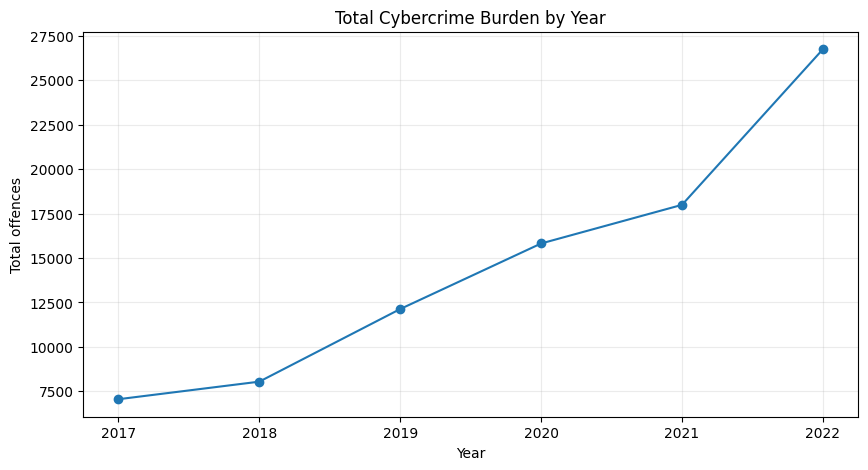

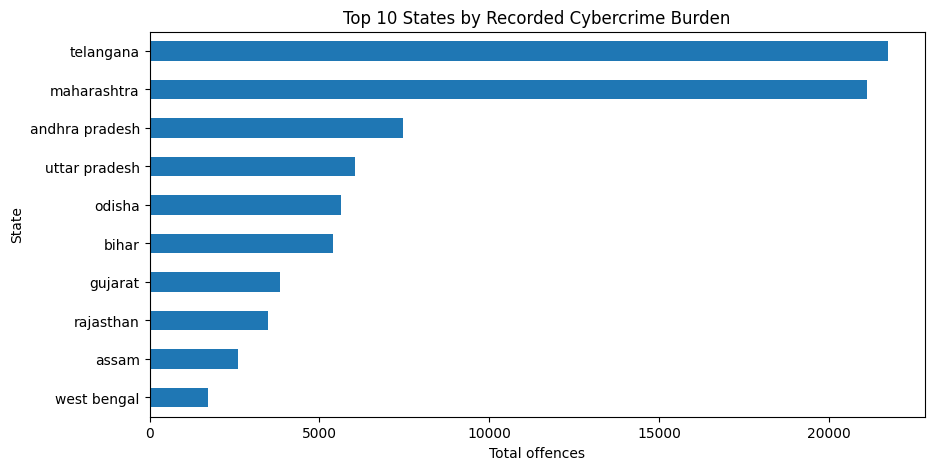

In [6]:
# 8.1 Total cybercrime trend
yearly = district.groupby('year')['total_offences_ip'].sum()

plt.figure(figsize=(10, 5))
yearly.plot(marker='o')
plt.title('Total Cybercrime Burden by Year')
plt.xlabel('Year')
plt.ylabel('Total offences')
plt.grid(alpha=0.25)
plt.show()

# 8.2 Top states over the complete period
top_states = (
    district.groupby('state_nm')['total_offences_ip']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_states.sort_values().plot(kind='barh')
plt.title('Top 10 States by Recorded Cybercrime Burden')
plt.xlabel('Total offences')
plt.ylabel('State')
plt.show()


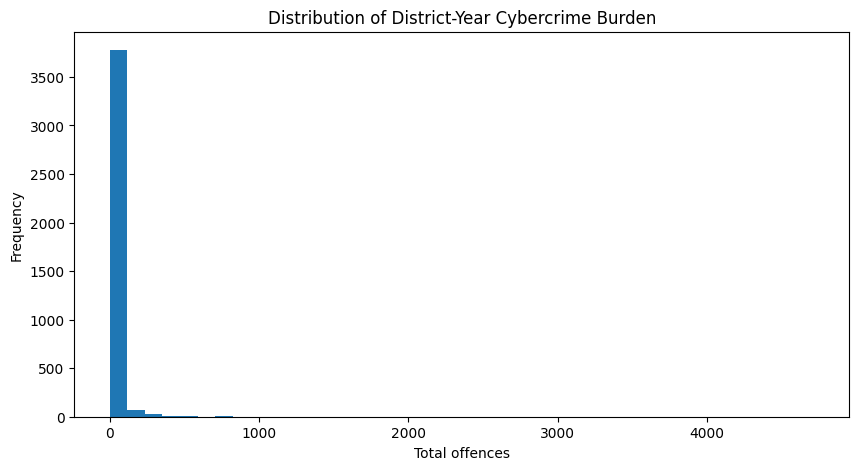

In [7]:
# 8.3 Distribution of district-level annual burden
values = district['total_offences_ip'].dropna().to_numpy()
plt.figure(figsize=(10, 5))
plt.hist(values, bins=40)
plt.title('Distribution of District-Year Cybercrime Burden')
plt.xlabel('Total offences')
plt.ylabel('Frequency')
plt.show()

## 9. Build the forecasting dataset

A row dated 2019 uses information from 2019 to predict the same district's 2020 total.

Therefore, the model never receives information from the future.

The target is shifted one calendar year relative to the feature record:
`target = total_offences_ip(year + 1)`.


In [8]:
# 9. Create next-year target
next_year_target = district[group_cols + ['total_offences_ip']].copy()
next_year_target['year'] = next_year_target['year'] - 1
next_year_target = next_year_target.rename(
    columns={'total_offences_ip': 'target_next_year_total'}
)

forecast = district.merge(
    next_year_target,
    on=group_cols,
    how='inner'
)

forecast = forecast[forecast['year'].between(2017, 2021)].copy()
forecast = forecast.dropna(subset=['target_next_year_total']).copy()
forecast['log_target'] = np.log1p(forecast['target_next_year_total'])

print("Forecasting rows:", forecast.shape)
display(
    forecast[['state_nm', 'district_name', 'year',
              'total_offences_ip', 'target_next_year_total']].head(10)
)


Forecasting rows: (2898, 36)


,state_nm,district_name,year,total_offences_ip,target_next_year_total
0,andaman and nicobar islands,nicobars,2017,0.0,0.0
1,andaman and nicobar islands,nicobars,2020,0.0,0.0
2,andaman and nicobar islands,north and middle andaman,2017,0.0,0.0
3,andaman and nicobar islands,north and middle andaman,2018,0.0,0.0
4,andaman and nicobar islands,north and middle andaman,2019,0.0,1.0
5,andaman and nicobar islands,north and middle andaman,2020,1.0,3.0
6,andaman and nicobar islands,north and middle andaman,2021,3.0,1.0
7,andaman and nicobar islands,south andamans,2017,0.0,3.0
8,andaman and nicobar islands,south andamans,2018,3.0,2.0
9,andaman and nicobar islands,south andamans,2019,2.0,0.0


## 10. Time-aware train / validation / test split

**Training target years:** 2018–2020  
**Validation target year:** 2021  
**Final test target year:** 2022

This is preferable to a random split for a forecasting problem because future observations must remain unseen during training.


In [9]:
# Feature year determines available information.
# Target year = feature year + 1.
train = forecast[forecast['year'].isin([2017, 2018, 2019])].copy()
val   = forecast[forecast['year'].isin([2020])].copy()
test  = forecast[forecast['year'].isin([2021])].copy()

model_features = ['year', 'state_nm', 'district_name'] + crime_cols

X_train, y_train = train[model_features].copy(), train['log_target'].copy()
X_val, y_val = val[model_features].copy(), val['log_target'].copy()
X_test, y_test = test[model_features].copy(), test['log_target'].copy()

cat_features = ['state_nm', 'district_name']
cat_indices = [model_features.index(c) for c in cat_features]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Validation target year:", int(val['year'].iloc[0]) + 1)
print("Test target year:", int(test['year'].iloc[0]) + 1)


Train: (1726, 34)
Validation: (591, 34)
Test: (581, 34)
Validation target year: 2021
Test target year: 2022


## 11. Baseline model

A strong and interpretable baseline is **persistence**:

> predict next year's total as equal to this year's total.

The ML model should beat this baseline; otherwise, the additional model complexity is not justified.


In [10]:
# Baseline: current-year total -> next-year total
baseline_pred = test['total_offences_ip'].fillna(
    train['target_next_year_total'].median()
).to_numpy()

baseline_actual = test['target_next_year_total'].to_numpy()

baseline_mae = mean_absolute_error(baseline_actual, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(baseline_actual, baseline_pred))
baseline_r2 = r2_score(baseline_actual, baseline_pred)

print(f"Baseline MAE : {baseline_mae:.2f}")
print(f"Baseline RMSE: {baseline_rmse:.2f}")
print(f"Baseline R²  : {baseline_r2:.4f}")


Baseline MAE : 33.09
Baseline RMSE: 265.60
Baseline R²  : 0.0138


## 12. Train the predictive model

### Model: CatBoostRegressor

CatBoost is selected because the problem contains:
- numerical crime counts
- high-cardinality categorical geography
- nonlinear relationships
- missing numerical values
- interactions between geography, time and crime type

The target is trained as `log1p(target)` to reduce the influence of very large districts. Predictions are converted back with `expm1`.


In [11]:
# 12. Train CatBoost on the log-transformed next-year target
model = CatBoostRegressor(
    loss_function='RMSE',
    eval_metric='RMSE',
    iterations=800,
    depth=7,
    learning_rate=0.04,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_indices,
    eval_set=(X_val, y_val),
    use_best_model=True,
    verbose=False
)

print("Best iteration:", model.get_best_iteration())


Best iteration: 423


In [12]:
# 13. Validation and final test predictions
val_pred = np.maximum(0, np.expm1(model.predict(X_val)))
test_pred = np.maximum(0, np.expm1(model.predict(X_test)))

val_actual = val['target_next_year_total'].to_numpy()
test_actual = test['target_next_year_total'].to_numpy()

def regression_report(actual, predicted, name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    nonzero = actual != 0
    mape = (
        np.mean(np.abs((actual[nonzero] - predicted[nonzero]) / actual[nonzero])) * 100
        if nonzero.any() else np.nan
    )
    print(f"--- {name} ---")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

val_metrics = regression_report(
    val_actual, val_pred, "Validation — target year 2021"
)
test_metrics = regression_report(
    test_actual, test_pred, "Final Test — target year 2022"
)


--- Validation — target year 2021 ---
MAE : 22.99
RMSE: 191.82
R²  : 0.0357
MAPE: 77.84%
--- Final Test — target year 2022 ---
MAE : 33.26
RMSE: 265.01
R²  : 0.0181
MAPE: 82.75%


In [13]:
# 14. Compare ML model against persistence baseline
comparison = pd.DataFrame({
    'Model': ['Persistence baseline', 'CatBoost forecasting model'],
    'MAE': [baseline_mae, test_metrics['MAE']],
    'RMSE': [baseline_rmse, test_metrics['RMSE']],
    'R2': [baseline_r2, test_metrics['R2']]
})

display(comparison)


,Model,MAE,RMSE,R2
0,Persistence baseline,33.091222,265.595884,0.013790
1,CatBoost forecasting model,33.257962,265.013079,0.018114


## 15. Feature importance

Feature importance shows which information the model relied on most strongly. This helps determine whether the model is learning from meaningful cybercrime indicators rather than only geography.


,feature,importance
33,total_offences_ip,42.848795
1,state_nm,20.729188
2,district_name,4.891209
24,cheating,3.361393
8,cheating_by_personation_by_using_computer_reso...,3.266523
0,year,2.855194
20,atms_fraud,2.346131
7,identity_theft,2.221086
32,other_offences,2.064288
22,otp_frauds,2.005040


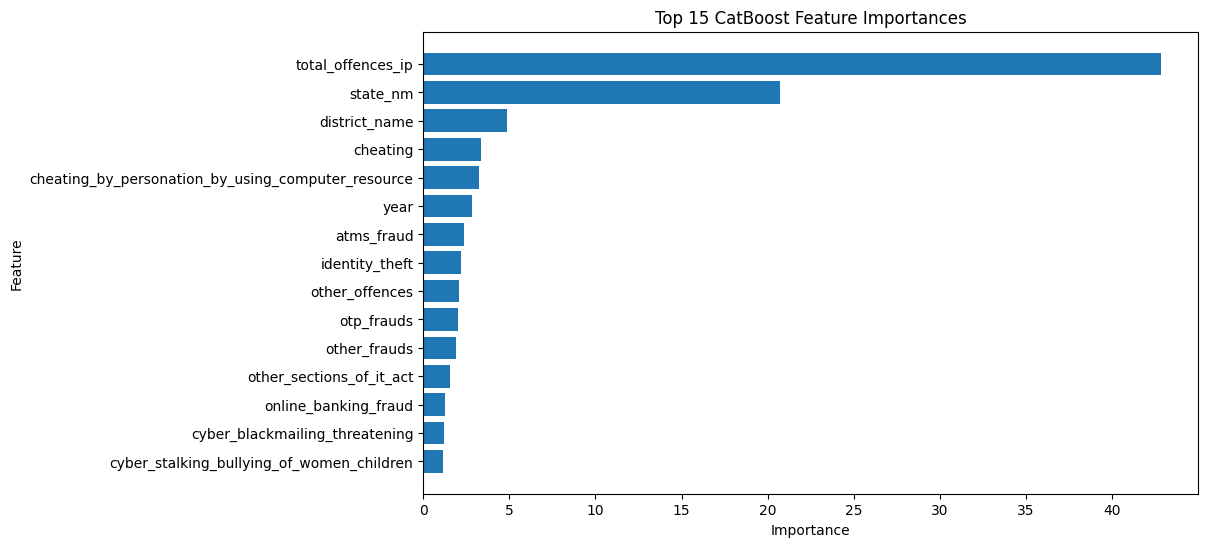

In [14]:
importance = pd.DataFrame({
    'feature': model_features,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

display(importance.head(15))

top_imp = importance.head(15).sort_values('importance')
plt.figure(figsize=(10, 6))
plt.barh(top_imp['feature'], top_imp['importance'])
plt.title('Top 15 CatBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


,state_nm,district_name,year,target_year,actual_total,predicted_total,absolute_error
1716,maharashtra,mumbai,2021,2022,4716.0,71.790271,4644.209729
2590,telangana,hyderabad,2021,2022,4151.0,9.205324,4141.794676
2848,uttar pradesh,gautam buddha nagar,2021,2022,755.0,12.678081,742.321919
2690,telangana,warangal,2021,2022,630.0,96.367487,533.632513
68,andhra pradesh,visakhapatnam,2021,2022,583.0,59.903027,523.096973
1786,maharashtra,thane,2021,2022,500.0,158.075855,341.924145
1753,maharashtra,pune,2021,2022,448.0,119.032926,328.967074
459,bihar,patna,2021,2022,345.0,43.369898,301.630102
315,assam,sonitpur,2021,2022,278.0,4.864812,273.135188
2672,telangana,sangareddy,2021,2022,284.0,20.257742,263.742258


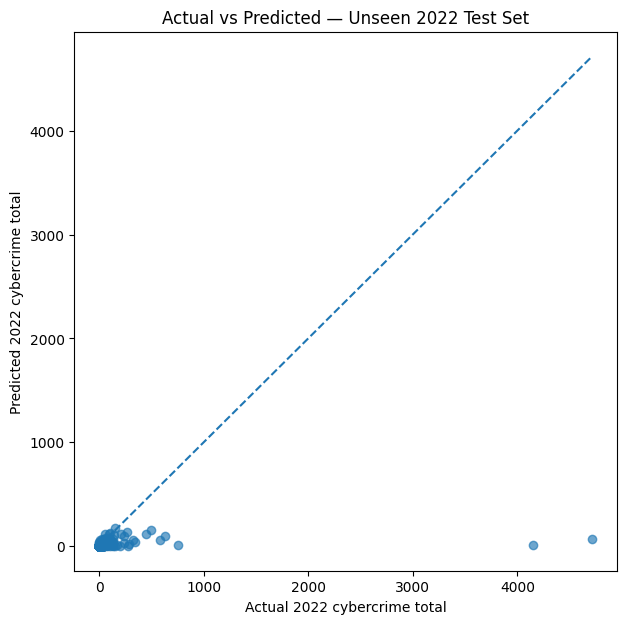

In [15]:
# 16. Actual vs predicted on the unseen 2022 test set
results = test[['state_nm', 'district_name', 'year']].copy()
results['target_year'] = results['year'] + 1
results['actual_total'] = test_actual
results['predicted_total'] = test_pred
results['absolute_error'] = np.abs(
    results['actual_total'] - results['predicted_total']
)

display(results.sort_values('absolute_error', ascending=False).head(15))

plt.figure(figsize=(7, 7))
plt.scatter(test_actual, test_pred, alpha=0.65)
limit = max(test_actual.max(), test_pred.max())
plt.plot([0, limit], [0, limit], linestyle='--')
plt.xlabel('Actual 2022 cybercrime total')
plt.ylabel('Predicted 2022 cybercrime total')
plt.title('Actual vs Predicted — Unseen 2022 Test Set')
plt.show()


## 17. Risk classification model

Exact annual offence counts are highly skewed and zero-inflated. Therefore, a second model predicts a practical **risk band**.

The thresholds are learned from the **training target only**:
- **Low:** 0 predicted/observed offences
- **Medium:** positive burden up to the 75th percentile of positive training targets
- **High:** above that threshold

This creates a more stable decision-support task than pretending that a few extreme districts can be predicted exactly.


In [16]:
# 17.1 Train a dedicated risk classifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix

positive_train = train.loc[train['target_next_year_total'] > 0, 'target_next_year_total']
high_threshold = positive_train.quantile(0.75)

def make_risk_label(value):
    if value <= 0:
        return 'Low'
    elif value <= high_threshold:
        return 'Medium'
    return 'High'

train['risk_label'] = train['target_next_year_total'].apply(make_risk_label)
val['risk_label'] = val['target_next_year_total'].apply(make_risk_label)
test['risk_label'] = test['target_next_year_total'].apply(make_risk_label)

risk_model = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=600,
    depth=7,
    learning_rate=0.04,
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False
)

risk_model.fit(
    X_train,
    train['risk_label'],
    cat_features=cat_indices,
    eval_set=(X_val, val['risk_label']),
    verbose=False
)

risk_pred = risk_model.predict(X_test).ravel()

risk_accuracy = accuracy_score(test['risk_label'], risk_pred)
risk_balanced_accuracy = balanced_accuracy_score(test['risk_label'], risk_pred)
risk_macro_f1 = f1_score(test['risk_label'], risk_pred, average='macro')

print(f"High-risk threshold: {high_threshold:.2f} offences")
print(f"Accuracy: {risk_accuracy:.4f}")
print(f"Balanced Accuracy: {risk_balanced_accuracy:.4f}")
print(f"Macro F1: {risk_macro_f1:.4f}")
print()
print(classification_report(
    test['risk_label'],
    risk_pred,
    labels=['Low', 'Medium', 'High'],
    zero_division=0
))

risk_cm = confusion_matrix(
    test['risk_label'],
    risk_pred,
    labels=['Low', 'Medium', 'High']
)
display(pd.DataFrame(
    risk_cm,
    index=['Actual Low', 'Actual Medium', 'Actual High'],
    columns=['Pred Low', 'Pred Medium', 'Pred High']
))


High-risk threshold: 33.00 offences
Accuracy: 0.7349
Balanced Accuracy: 0.6875
Macro F1: 0.7005

              precision    recall  f1-score   support

         Low       0.80      0.90      0.85       262
      Medium       0.62      0.65      0.64       197
        High       0.78      0.51      0.62       122

    accuracy                           0.73       581
   macro avg       0.74      0.69      0.70       581
weighted avg       0.74      0.73      0.73       581



,Pred Low,Pred Medium,Pred High
Actual Low,237,24,1
Actual Medium,53,128,16
Actual High,6,54,62


## 18. Reusable prediction function

This is the actual model-use layer. A user supplies a **current-year district profile** and the model forecasts the next year's cybercrime burden.

The function accepts the same crime-category columns used during training. Missing crime categories are allowed because CatBoost handles missing numerical values.


In [17]:
# 18. Reusable prediction utility
def predict_next_year(state, district_name, year, crime_profile):
    """
    Predict next-year cybercrime burden and risk.

    Parameters
    ----------
    state : str
        State name.
    district_name : str
        District name.
    year : int
        Current year. The model predicts year + 1.
    crime_profile : dict
        Current-year crime counts. Keys should match the crime columns.

    Returns
    -------
    dict
        Numeric forecast plus model-predicted risk level.
    """
    row = {
        'year': int(year),
        'state_nm': str(state).lower().strip(),
        'district_name': str(district_name).lower().strip()
    }

    for col in crime_cols:
        if col != 'total_offences_ip':
            row[col] = crime_profile.get(col, np.nan)

    # The current total is an important lag feature.
    row['total_offences_ip'] = crime_profile.get('total_offences_ip', np.nan)

    input_df = pd.DataFrame([row], columns=model_features)

    predicted_total = max(
        0,
        float(np.expm1(model.predict(input_df)[0]))
    )
    predicted_risk = risk_model.predict(input_df).ravel()[0]

    return {
        'district': district_name,
        'state': state,
        'forecast_year': int(year) + 1,
        'predicted_cybercrime_total': round(predicted_total, 2),
        'predicted_risk_level': str(predicted_risk)
    }

print("Prediction function ready.")


Prediction function ready.


In [18]:
# 19. Example: use the model with an actual 2021 district profile
example_row = test.iloc[0]

example_profile = {
    col: example_row[col]
    for col in crime_cols[:-1]
}

example_prediction = predict_next_year(
    state=example_row['state_nm'],
    district_name=example_row['district_name'],
    year=int(example_row['year']),
    crime_profile=example_profile
)

print(example_prediction)
print("\nActual next-year total:", float(example_row['target_next_year_total']))
print("Actual risk level:", example_row['risk_label'])


{'district': 'north and middle andaman', 'state': 'andaman and nicobar islands', 'forecast_year': 2022, 'predicted_cybercrime_total': 0.84, 'predicted_risk_level': 'Low'}

Actual next-year total: 1.0
Actual risk level: Medium


In [19]:
# 20. Save trained models and metadata
MODEL_FILE = "satark_cybercrime_forecaster.cbm"
RISK_MODEL_FILE = "satark_cybercrime_risk_classifier.cbm"

model.save_model(MODEL_FILE)
risk_model.save_model(RISK_MODEL_FILE)

metadata = {
    'model_features': model_features,
    'categorical_features': cat_features,
    'target': 'next_year_total_offences_ip',
    'risk_target': 'Low / Medium / High',
    'high_risk_threshold_from_training_positive_targets': float(high_threshold),
    'train_target_years': [2018, 2019, 2020],
    'validation_target_year': 2021,
    'test_target_year': 2022
}

with open("satark_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

results['predicted_risk'] = risk_pred
results['actual_risk'] = test['risk_label'].to_numpy()
results.to_csv("satark_2022_predictions.csv", index=False)

print("Saved:")
print("-", MODEL_FILE)
print("-", RISK_MODEL_FILE)
print("- satark_model_metadata.json")
print("- satark_2022_predictions.csv")


Saved:
- satark_cybercrime_forecaster.cbm
- satark_cybercrime_risk_classifier.cbm
- satark_model_metadata.json
- satark_2022_predictions.csv


# 21. Final interpretation

This model should be described as a **district-level next-year cybercrime forecasting model**, not as a generic classifier.

### What it predicts
`Current-year district cybercrime profile → next-year total cybercrime burden`

### Why the evaluation is stronger
The final 2022 test set is temporally separated from the training data. The model never sees 2022 target values during training.

### Why the target is valid
The target is the dataset's original `total_offences_ip` measured in the following year. It is not constructed by summing scaled predictors.

### Practical use
The continuous forecast can support:
- district prioritisation
- cyber-policing resource allocation
- awareness campaign targeting
- early identification of rising cybercrime burden

The risk label is a decision-support layer over the forecast; it should not be interpreted as a causal or official law-enforcement risk classification.
